In [1]:
# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion
# For the minor planets
from tudatpy.data import horizons

# Additional import
import os           # for the extraction of asteroid kernels


In [2]:
# Step 1: Setup Conditions/ Basic Conditions

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
# Start dat = 25th of April 2004 (arbitrary choice)
# Tudat works in J2000, so use seconds
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch() - 12 * 3600
simulation_end_epoch   = simulation_start_epoch + 20 * constants.JULIAN_YEAR


# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create_1_2 = [
    "Sun",
]

# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create_3 = [
    "Sun",
    "Earth",
    "Mercury",
    "Venus",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    "Ceres": [1, 62.10], 
    "Pallas": [2, 13.73],
    "Juno": [3, 1.61],
    "Vesta": [4, 17.38],
    "Hebe": [6, 0.89],
    "Iris": [7, 0.73],
    "Flora": [8, 0.27],
    "Metis": [9, 0.44],
    "Hygiea": [10, 5.97],
    "Irene": [14, 0.25],
    "Eunomia": [15, 1.88],
    "Psyche": [16, 1.65],
    "Fortuna": [19, 0.42],
    "Thalia": [23, 0.15],
    "Amphitrite": [29, 0.98],
    "Daphne": [41, 0.56],
    "Europa": [52, 1.48],
    "Bamberga": [324, 0.71],
    "Davida": [511, 1.14],
    "Herculina": [532, 0.66],
    "Interamnia": [704, 2.65]
}

In [3]:
# Manually add 1998 TU3
asteroid_name = "66146"


# Combine all bodies into one large list
bodies_to_create_12 = larger_bodies_to_create_1_2 + [asteroid_name]
bodies_to_create_3 = larger_bodies_to_create_3 + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris


# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings_12 = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create_1_2, 
    base_frame_origin = 'SSB',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000

# Pull on the data already known for the larger bodies
body_settings_3 = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create_3, 
    base_frame_origin = 'SSB',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Manually add empty settings for TU3
body_settings_12.add_empty_settings(asteroid_name)
body_settings_3.add_empty_settings(asteroid_name)

# Know that I then create the environment below before the acceleration

In [4]:
# The 21 asteroids:

# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 

# Loop through the dictionary and load the corresponding .bsp file
for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
    # Calculate the NAIF ID from the data list
    # E.g. Juno has 20000003 (ID: 3)
    ast_id = data[0]
    naif_id = 20000000 + ast_id
    
    # Then extract the ephemeris for each asteroid
    kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
    if os.path.exists(kernel_path):
        spice.load_kernel(kernel_path)
        print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
    else:
        print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")



1.Successfully loaded the kernel for Ceres using file: 20000001.bsp
2.Successfully loaded the kernel for Pallas using file: 20000002.bsp
3.Successfully loaded the kernel for Juno using file: 20000003.bsp
4.Successfully loaded the kernel for Vesta using file: 20000004.bsp
5.Successfully loaded the kernel for Hebe using file: 20000006.bsp
6.Successfully loaded the kernel for Iris using file: 20000007.bsp
7.Successfully loaded the kernel for Flora using file: 20000008.bsp
8.Successfully loaded the kernel for Metis using file: 20000009.bsp
9.Successfully loaded the kernel for Hygiea using file: 20000010.bsp
10.Successfully loaded the kernel for Irene using file: 20000014.bsp
11.Successfully loaded the kernel for Eunomia using file: 20000015.bsp
12.Successfully loaded the kernel for Psyche using file: 20000016.bsp
13.Successfully loaded the kernel for Fortuna using file: 20000019.bsp
14.Successfully loaded the kernel for Thalia using file: 20000023.bsp
15.Successfully loaded the kernel for 

In [5]:
sigma_GM_asteroids = [
    0.43,  # Ceres
    0.34,  # Pallas
    0.12,  # Juno
    0.27,  # Vesta
    0.20,  # Eros (NEAR asteroid)
    0.22,  # Hebe
    0.18,  # Iris
    0.06,  # Flora
    0.14,  # Metis
    1.03,  # Hygiea
    0.11,  # Irene
    0.20,  # Eunomia
    0.46,  # Psyche
    0.07,  # Fortuna
    0.09,  # Thalia
    0.20,  # Amphitrite
    0.23,  # Daphne
    1.11,  # Europa
    0.13,  # Bamberga
    0.79,  # Davida
    0.37,  # Herculina
    0.87,  # Interamnia
]

In [6]:
# Extract only the asteroids' names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())

buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon

for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu = (data[1]) * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units)

    # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
    naif_id = 20000000 + ast_id

    try:
        
        # To fix Tudat finding the data:

        # This solves the "Object has no attribute naif_id" error by 
        # linking the name and ID in the global SPICE map.
        # spice.set_id_to_name_mapping(naif_id, name)

        naif_id_str = str(2000000 + ast_id)

        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
            frame_origin = 'Sun',               # The SPK files were w.r.t the Sun
            frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
            body_name_to_use = naif_id_str)


        # Create empty slots, then insert the asteroids
        body_settings_3.add_empty_settings(name)
        # Assign ephemeris
        body_settings_3.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast

        # # Know that Tudat will be looking for names of the asteroids, while they're named after their ID's
        # # Thus, link the name to the specific NAIF ID loaded in the .bsp file
        # body_settings.get(name).ephemeris_settings.make_multi_arc_ephemeris = False # so that Tudat won't try to string together things
        # body_settings.get(name).ephemeris_settings.naif_id = str(naif_id)           # getting the info from the naif_id and not the name :)


        # Assign gravity field (w. the central function that manually adds the mu)
        body_settings_3.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")

    except Exception as e:
        print(f"Could not fetch data for {name}: {e}")


# Manually add empty settings for TU3
body_settings_12.add_empty_settings(asteroid_name)
body_settings_3.add_empty_settings(asteroid_name)

# Know that I create the environment below, when creating body_system


 1. Successfully configured Ceres (ID: 1 / NAIF: 20000001)
 2. Successfully configured Pallas (ID: 2 / NAIF: 20000002)
 3. Successfully configured Juno (ID: 3 / NAIF: 20000003)
 4. Successfully configured Vesta (ID: 4 / NAIF: 20000004)
 5. Successfully configured Hebe (ID: 6 / NAIF: 20000006)
 6. Successfully configured Iris (ID: 7 / NAIF: 20000007)
 7. Successfully configured Flora (ID: 8 / NAIF: 20000008)
 8. Successfully configured Metis (ID: 9 / NAIF: 20000009)
 9. Successfully configured Hygiea (ID: 10 / NAIF: 20000010)
 10. Successfully configured Irene (ID: 14 / NAIF: 20000014)
 11. Successfully configured Eunomia (ID: 15 / NAIF: 20000015)
 12. Successfully configured Psyche (ID: 16 / NAIF: 20000016)
 13. Successfully configured Fortuna (ID: 19 / NAIF: 20000019)
 14. Successfully configured Thalia (ID: 23 / NAIF: 20000023)
 15. Successfully configured Amphitrite (ID: 29 / NAIF: 20000029)
 16. Successfully configured Daphne (ID: 41 / NAIF: 20000041)
 17. Successfully configured E

In [7]:
# Step 3: Create the Propagation Setup

bodies_to_propagate = ["66146"]

central_bodies_12 = ["Sun"]
central_bodies_3 = ["Sun"]      # or SSB?

In [8]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic

# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7) + 0.1 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6   # + 0.07 * 10**6  # m

body_settings_12.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

body_settings_3.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

In [9]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

# A_2_TU3_AUdays2 = avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
# A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
A_2_TU3_uncertainty_ms2 = A_2_TU3_uncertainty_AUdays2 * 149597870691 / ((24 * 3600)**2)

A_2_TU3_ms2_error = A_2_TU3_ms2 + A_2_TU3_uncertainty_ms2

print(A_2_TU3_ms2_error)

The Yarkovksy parameter for TU3: -8.971192934635577e-15 AU / days^2
6.247795079478349e-15
-5.457691939085512e-14


In [10]:
# Thus, the environment becomes:
body_system_12 = environment_setup.create_system_of_bodies(body_settings_12)
body_system_3 = environment_setup.create_system_of_bodies(body_settings_3)

In [11]:
# 1. The Sun as a point-mass

# The planets
accelerations_planets_1 = {
    "Sun": [
        # The Sun's gravity 
        propagation_setup.acceleration.point_mass_gravity(), 
    ],
}

acceleration_dict_1 = {"66146": accelerations_planets_1}

# The planets
accelerations_planets_2 = {
    "Sun": [
        # The Sun's gravity 
        # propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2),
        # propagation_setup.acceleration.radiation_pressure(), 
    ],
}

acceleration_dict_2 = {"66146": accelerations_planets_2}


# The planets
accelerations_planets_3 = {
    "Sun": [
        # The Sun's gravity 
        # propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2), 
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}


# The asteroids

accelerations_asteroids = {
    
    asteroid_name: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name in smaller_bodies_list
}


# Merge dictionaries
accelerations_merged_3 = (
    accelerations_planets_3 |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict_3 = {
    "66146": accelerations_merged_3
}


In [12]:
# Step 5: Define the Initial States of Each Body

sun_gravitational_parameter = body_system_12.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    4.543863572576185E+07 * 1e3,   # X  [m]
    -9.673019712424231E+07 * 1e3,  # Y  [m]
    -2.313075952057116E+06 * 1e3,  # Z  [m]
    3.661410298575712E+01 * 1e3,   # VX [m/s]
    -1.757686929389374E+00 * 1e3,  # VY [m/s]
    -3.350242409196601E+00 * 1e3   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

sigma_a = 25.55              # m
sigma_e = 2.8966e-9          # dimensionless
sigma_i = 8.3577e-10         # rad
sigma_peri = 1.7675e-8       # rad
sigma_node = 1.5686e-8       # rad
sigma_true_anomaly = 1.08e-7 # rad (estimated from sigma_M)

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0],                 #meters
    eccentricity = test_initial_TU3_array[1],                    #unitless
    inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3],
    longitude_of_ascending_node = test_initial_TU3_array[4],
    true_anomaly = test_initial_TU3_array[5],                
)

system_initial_state = initial_state_TU3


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) # 15 years after the epoch begins

# Create numerical integrator settings
fixed_step_size = 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)



Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611


In [13]:
# The first case:

# Create the acceleration model
acceleration_models_1 = (
    propagation_setup.create_acceleration_models(
        body_system_12,
        acceleration_dict_1,
        bodies_to_propagate,
        central_bodies_12
    )
)

# Propagating TU3 with the created system
propagator_settings_1 = propagation_setup.propagator.translational(
    central_bodies_12,
    acceleration_models_1,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_1 = simulator.create_dynamics_simulator(
    body_system_12, propagator_settings_1
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_1 = dynamics_simulator_1.propagation_results.state_history

states_array_TU3_1 = result2array(states_TU3_1)

In [14]:
# The second case:

# Create the acceleration model
acceleration_models_2 = (
    propagation_setup.create_acceleration_models(
        body_system_12,
        acceleration_dict_2,
        bodies_to_propagate,
        central_bodies_12
    )
)

# Propagating TU3 with the created system
propagator_settings_2 = propagation_setup.propagator.translational(
    central_bodies_12,
    acceleration_models_2,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_2 = simulator.create_dynamics_simulator(
    body_system_12, propagator_settings_2
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_2 = dynamics_simulator_2.propagation_results.state_history

states_array_TU3_2 = result2array(states_TU3_2)

In [15]:
# The first case:

# Create the acceleration model
acceleration_models_3 = (
    propagation_setup.create_acceleration_models(
        body_system_3,
        acceleration_dict_3,
        bodies_to_propagate,
        central_bodies_3
    )
)

# Propagating TU3 with the created system
propagator_settings_3 = propagation_setup.propagator.translational(
    central_bodies_3,
    acceleration_models_3,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_3 = simulator.create_dynamics_simulator(
    body_system_3, propagator_settings_3
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_3 = dynamics_simulator_3.propagation_results.state_history

states_array_TU3_3 = result2array(states_TU3_3)

In [16]:
# Extract the times 
times = states_array_TU3_1[:,0]

In [17]:
from tudatpy.kernel.astro import element_conversion
import numpy as np

def kep_orbit_elements(states_of_TU3, body_system_i):
    
    """
    A function that collects the 6 Keplerian elements at each position of TU3 (each time step)
    """

    a_kep_list = []      # meters
    e_kep_list = []      # unitless
    i_kep_list = []      # radians
    omega_kep_list = []  # rad, the argument of periapsis 
    RAAN_kep_list = []   # rad, Right Ascension of the Ascending Node
    nu_kep_list = []     # true motion, deg/days
    epochs = []


    mu_sun = body_system_i.get("Sun").gravitational_parameter

    kepler_history = {}

    for epoch, state in states_of_TU3.items():

        # Convert from Cartesian to Keplerian coordinates
        kepler = element_conversion.cartesian_to_keplerian(
            cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
            gravitational_parameter = mu_sun
        )

        # Fill up the dictionary
        kepler_history[epoch] = kepler

        a_kep = kepler[0]      # meters
        #print(f"a = {a_kep}")
        e_kep = kepler[1]      # unitless
        i_kep = kepler[2]      # radians
        omega_kep = kepler[3]  # rad, the argument of periapsis 
        RAAN_kep = kepler[4]   # rad, Right Ascension of the Ascending Node
        nu_kep = kepler[5]     # rad, true anomaly (angle between body, SSB and perihelion)    

        a_kep_list.append(a_kep)      # meters
        e_kep_list.append(e_kep)      # unitless
        i_kep_list.append(i_kep)      # radians
        omega_kep_list.append(omega_kep)  # rad, the argument of periapsis 
        RAAN_kep_list.append(RAAN_kep)   # rad, Right Ascension of the Ascending Node
        nu_kep_list.append(nu_kep)

        epochs.append(epoch)

    # Unwrap omega (so that there aren't any huge jumps)
    # Unwrap the angles :)
    # Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
    omega_values = np.unwrap(np.degrees(omega_kep_list))

    return a_kep_list, e_kep_list, omega_values, epochs, kepler_history
            

In [18]:
_, _, _, _, kepler_history = kep_orbit_elements(states_TU3_1, body_system_12)

true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

In [19]:
a_kep_1, e_kep_1, omega_values_1, epochs, _ = kep_orbit_elements(states_TU3_1, body_system_12)
a_kep_2, e_kep_2, omega_values_2, epochs, _ = kep_orbit_elements(states_TU3_2, body_system_12)
a_kep_3, e_kep_3, omega_values_3, epochs, _ = kep_orbit_elements(states_TU3_3, body_system_3)

In [20]:
epochs_years = 2000 + np.array(epochs) / (365.25 * 24 * 3600)
first_perihelion_in_years = 2000 + np.array(epoch_perihelion_list[0]) / (365.25 * 24 * 3600)

one_AU = 149597870691   # meters
a_kep_1_AU = (np.array(a_kep_1) / one_AU)
a_kep_2_AU = (np.array(a_kep_2) / one_AU)
a_kep_3_AU = (np.array(a_kep_3) / one_AU)

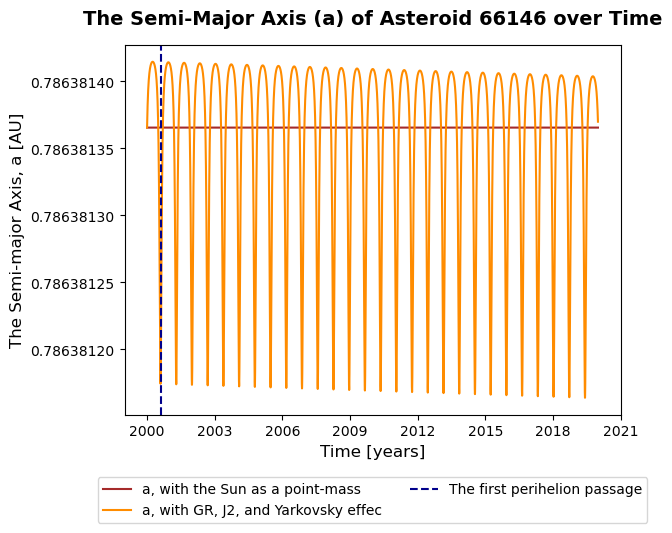

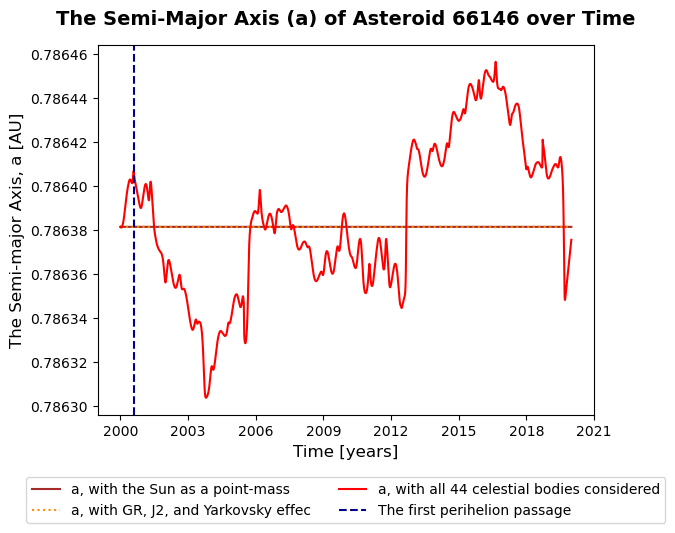

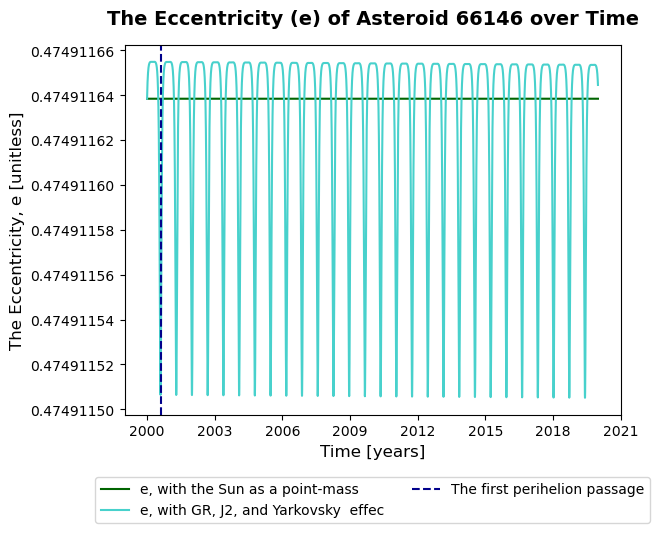

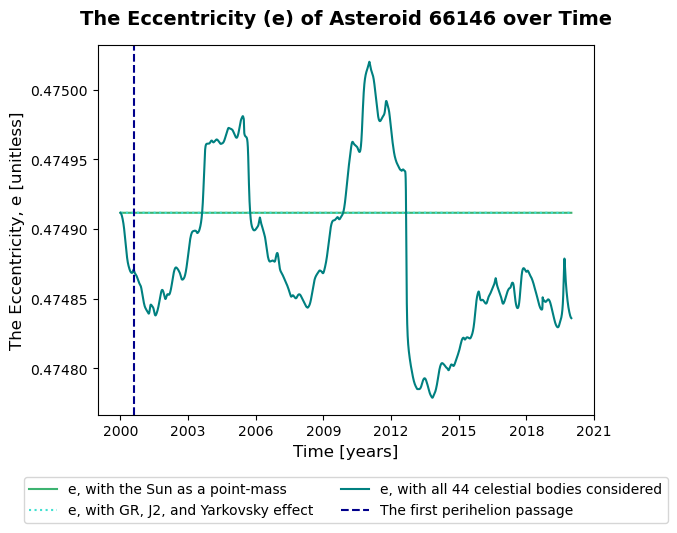

In [21]:
# Plot 1

plt.plot(epochs_years, a_kep_1_AU, color='brown', label='a, with the Sun as a point-mass')
plt.plot(epochs_years, a_kep_2_AU, color='darkorange', label='a, with GR, J2, and Yarkovsky effec')
# plt.plot(epochs_years, a_kep_3_AU, color='red', label='All bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Semi-Major Axis (a) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Semi-major Axis, a [AU]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

# Set ticks at 2000, 2002, 2004, ...
xmin, xmax = plt.xlim()
ticks = np.arange(np.floor(xmin/2)*2 + 2, np.ceil(xmax/2)*2, 3)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])

plt.show()

#Plot 2

plt.plot(epochs_years, a_kep_1_AU, color='brown', label='a, with the Sun as a point-mass')
plt.plot(epochs_years, a_kep_2_AU, color='darkorange', linestyle=':', label='a, with GR, J2, and Yarkovsky effec')
plt.plot(epochs_years, a_kep_3_AU, color='red', label='a, with all 44 celestial bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Semi-Major Axis (a) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Semi-major Axis, a [AU]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


# Plot 3

plt.plot(epochs_years, e_kep_1, color='darkgreen', label='e, with the Sun as a point-mass')
plt.plot(epochs_years, e_kep_2, color='mediumturquoise', label='e, with GR, J2, and Yarkovsky  effec')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Eccentricity (e) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Eccentricity, e [unitless]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


#Plot 4

plt.plot(epochs_years, e_kep_1, color='mediumseagreen', label='e, with the Sun as a point-mass')
plt.plot(epochs_years, e_kep_2, color='turquoise', linestyle=':', label='e, with GR, J2, and Yarkovsky effect')
plt.plot(epochs_years, e_kep_3, color='teal', label='e, with all 44 celestial bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Eccentricity (e) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Eccentricity, e [unitless]', fontsize=12)

# plt.legend()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:9: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:25: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:26: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:27: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will n

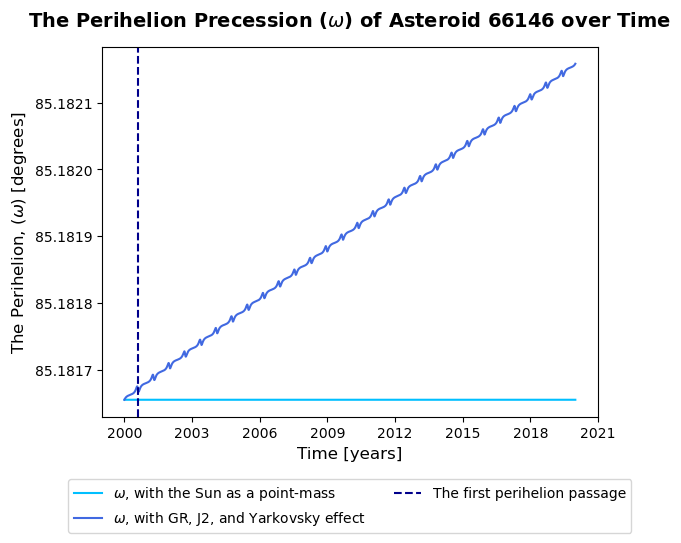

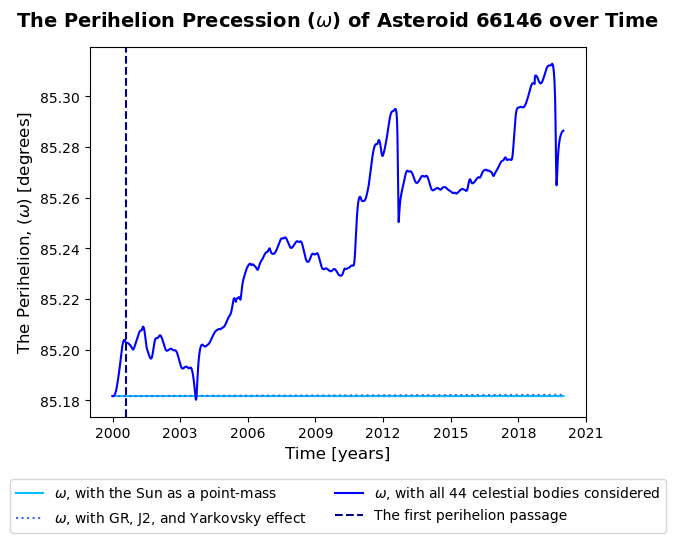

In [22]:
# Plot 5

plt.plot(epochs_years, omega_values_1, color='deepskyblue', label=f'$\omega$, with the Sun as a point-mass')
plt.plot(epochs_years, omega_values_2, color='royalblue', label=f'$\omega$, with GR, J2, and Yarkovsky effect')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title(f'The Perihelion Precession ($\omega$) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Perihelion, ($\omega$) [degrees]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


#Plot 6

plt.plot(epochs_years, omega_values_1, color='deepskyblue', label=f'$\omega$, with the Sun as a point-mass')
plt.plot(epochs_years, omega_values_2, color='royalblue', linestyle=':', label=f'$\omega$, with GR, J2, and Yarkovsky effect')
plt.plot(epochs_years, omega_values_3, color='blue', label=f'$\omega$, with all 44 celestial bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title(f'The Perihelion Precession ($\omega$) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Perihelion, ($\omega$) [degrees]', fontsize=12)

# plt.legend()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()

In [23]:
# Finding the slope

# Arcseconds
omega_arcseconds = omega_values_2 * 3600

# The epochs are currently in seconds, when they should be per century
epochs_centuery = np.array(epochs) / (100 * 365 * 24 * 3600)

print(np.polyfit(epochs,np.degrees(omega_values_2),1)[0])
print(f"The perihelion precession: {np.polyfit(epochs_centuery,omega_arcseconds,1)[0]} arcesconds/ century")

4.558909886379258e-11
The perihelion precession: 9.033321827706795 arcesconds/ century


In [24]:

# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create_1_2 = [
    "Sun",
]

# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create_3 = [
    "Sun",
    "Earth",
    "Mercury",
    "Venus",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    "Ceres": [1, 62.10], 
    "Pallas": [2, 13.73],
    "Juno": [3, 1.61],
    "Vesta": [4, 17.38],
    "Hebe": [6, 0.89],
    "Iris": [7, 0.73],
    "Flora": [8, 0.27],
    "Metis": [9, 0.44],
    "Hygiea": [10, 5.97],
    "Irene": [14, 0.25],
    "Eunomia": [15, 1.88],
    "Psyche": [16, 1.65],
    "Fortuna": [19, 0.42],
    "Thalia": [23, 0.15],
    "Amphitrite": [29, 0.98],
    "Daphne": [41, 0.56],
    "Europa": [52, 1.48],
    "Bamberga": [324, 0.71],
    "Davida": [511, 1.14],
    "Herculina": [532, 0.66],
    "Interamnia": [704, 2.65]
}

# Manually add 1998 TU3
asteroid_name = "66146"


# Combine all bodies into one large list
bodies_to_create_12_error = larger_bodies_to_create_1_2 + [asteroid_name]
bodies_to_create_3_error = larger_bodies_to_create_3 + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris


# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings_12_error = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create_1_2, 
    base_frame_origin = 'SSB',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000

# Pull on the data already known for the larger bodies
body_settings_3_error = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create_3, 
    base_frame_origin = 'SSB',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Manually add empty settings for TU3
body_settings_12_error.add_empty_settings(asteroid_name)
body_settings_3_error.add_empty_settings(asteroid_name)



# Know that I then create the environment below before the acceleration

# The 21 asteroids:

# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 

# Loop through the dictionary and load the corresponding .bsp file
for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
    # Calculate the NAIF ID from the data list
    # E.g. Juno has 20000003 (ID: 3)
    ast_id = data[0]
    naif_id = 20000000 + ast_id
    
    # Then extract the ephemeris for each asteroid
    kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
    if os.path.exists(kernel_path):
        spice.load_kernel(kernel_path)
        print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
    else:
        print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

sigma_GM_asteroids = [
    0.43,  # Ceres
    0.34,  # Pallas
    0.12,  # Juno
    0.27,  # Vesta
    0.20,  # Eros (NEAR asteroid)
    0.22,  # Hebe
    0.18,  # Iris
    0.06,  # Flora
    0.14,  # Metis
    1.03,  # Hygiea
    0.11,  # Irene
    0.20,  # Eunomia
    0.46,  # Psyche
    0.07,  # Fortuna
    0.09,  # Thalia
    0.20,  # Amphitrite
    0.23,  # Daphne
    1.11,  # Europa
    0.13,  # Bamberga
    0.79,  # Davida
    0.37,  # Herculina
    0.87,  # Interamnia
]

# Extract only the asteroids' names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())

buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon

for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu_error = (data[1] + sigma_GM_asteroids[i-1]) * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units)

    # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
    naif_id = 20000000 + ast_id

    try:
        
        # To fix Tudat finding the data:

        # This solves the "Object has no attribute naif_id" error by 
        # linking the name and ID in the global SPICE map.
        # spice.set_id_to_name_mapping(naif_id, name)

        naif_id_str = str(2000000 + ast_id)

        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast_error = environment_setup.ephemeris.direct_spice(
            frame_origin = 'Sun',               # The SPK files were w.r.t the Sun
            frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
            body_name_to_use = naif_id_str)


        # Create empty slots, then insert the asteroids
        body_settings_3_error.add_empty_settings(name)
        # Assign ephemeris
        body_settings_3_error.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast_error

        # # Know that Tudat will be looking for names of the asteroids, while they're named after their ID's
        # # Thus, link the name to the specific NAIF ID loaded in the .bsp file
        # body_settings.get(name).ephemeris_settings.make_multi_arc_ephemeris = False # so that Tudat won't try to string together things
        # body_settings.get(name).ephemeris_settings.naif_id = str(naif_id)           # getting the info from the naif_id and not the name :)


        # Assign gravity field (w. the central function that manually adds the mu)
        body_settings_3_error.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu_error)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")

    except Exception as e:
        print(f"Could not fetch data for {name}: {e}")


# Manually add empty settings for TU3
body_settings_12_error.add_empty_settings(asteroid_name)
body_settings_3_error.add_empty_settings(asteroid_name)

# Know that I create the environment below, when creating body_system

# Step 3: Create the Propagation Setup

bodies_to_propagate = ["66146"]

central_bodies_12 = ["Sun"]
central_bodies_3 = ["Sun"]      # or SSB?

# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic

# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7) + 0.1 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6 + 0.07 * 10**6  # m

body_settings_12_error.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

body_settings_3_error.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)


# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

# A_2_TU3_AUdays2 = avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
# A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
A_2_TU3_uncertainty_ms2 = A_2_TU3_uncertainty_AUdays2 * 149597870691 / ((24 * 3600)**2)

A_2_TU3_ms2_error = A_2_TU3_ms2 + A_2_TU3_uncertainty_ms2

print(A_2_TU3_ms2_error)

# Thus, the environment becomes:
body_system_12_error = environment_setup.create_system_of_bodies(body_settings_12_error)
body_system_3_error = environment_setup.create_system_of_bodies(body_settings_3_error)

# 1. The Sun as a point-mass

# The planets
accelerations_planets_1_error = {
    "Sun": [
        # The Sun's gravity 
        propagation_setup.acceleration.point_mass_gravity(), 
    ],
}

acceleration_dict_1 = {"66146": accelerations_planets_1_error}

# The planets
accelerations_planets_2_error = {
    "Sun": [
        # The Sun's gravity 
        # propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2_error),
        # propagation_setup.acceleration.radiation_pressure(), 
    ],
}

acceleration_dict_2_error = {"66146": accelerations_planets_2_error}


# The planets
accelerations_planets_3_error = {
    "Sun": [
        # The Sun's gravity 
        # propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2_error), 
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}


# The asteroids

accelerations_asteroids_error = {
    
    asteroid_name: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name in smaller_bodies_list
}


# Merge dictionaries
accelerations_merged_3_error = (
    accelerations_planets_3_error |
    accelerations_asteroids_error
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict_3_error = {
    "66146": accelerations_merged_3_error
}

# Step 5: Define the Initial States of Each Body

sun_gravitational_parameter = body_system_12_error.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    4.543863572576185E+07 * 1e3,   # X  [m]
    -9.673019712424231E+07 * 1e3,  # Y  [m]
    -2.313075952057116E+06 * 1e3,  # Z  [m]
    3.661410298575712E+01 * 1e3,   # VX [m/s]
    -1.757686929389374E+00 * 1e3,  # VY [m/s]
    -3.350242409196601E+00 * 1e3   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

sigma_a = 25.55              # m
sigma_e = 2.8966e-9          # dimensionless
sigma_i = 8.3577e-10         # rad
sigma_peri = 1.7675e-8       # rad
sigma_node = 1.5686e-8       # rad
sigma_true_anomaly = 1.08e-7 # rad (estimated from sigma_M)

initial_state_TU3_error = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0] + sigma_a,                 #meters
    eccentricity = test_initial_TU3_array[1] + sigma_e,                    #unitless
    inclination = test_initial_TU3_array[2] + sigma_i,                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3] + sigma_peri,
    longitude_of_ascending_node = test_initial_TU3_array[4] + sigma_node,
    true_anomaly = test_initial_TU3_array[5] + sigma_true_anomaly,                
)

system_initial_state_error = initial_state_TU3_error


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) # 15 years after the epoch begins

# Create numerical integrator settings
fixed_step_size = 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)

# The first case:

# Create the acceleration model
acceleration_models_1_error = (
    propagation_setup.create_acceleration_models(
        body_system_12_error,
        acceleration_dict_1,
        bodies_to_propagate,
        central_bodies_12
    )
)

# Propagating TU3 with the created system
propagator_settings_1_error = propagation_setup.propagator.translational(
    central_bodies_12,
    acceleration_models_1_error,
    bodies_to_propagate,
    system_initial_state_error,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_1_error = simulator.create_dynamics_simulator(
    body_system_12_error, propagator_settings_1_error
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_1_error = dynamics_simulator_1_error.propagation_results.state_history

states_array_TU3_1_error = result2array(states_TU3_1_error)

# The second case:

# Create the acceleration model
acceleration_models_2_error = (
    propagation_setup.create_acceleration_models(
        body_system_12_error,
        acceleration_dict_2_error,
        bodies_to_propagate,
        central_bodies_12
    )
)

# Propagating TU3 with the created system
propagator_settings_2_error = propagation_setup.propagator.translational(
    central_bodies_12,
    acceleration_models_2_error,
    bodies_to_propagate,
    system_initial_state_error,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_2_error = simulator.create_dynamics_simulator(
    body_system_12_error, propagator_settings_2_error
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_2_error = dynamics_simulator_2_error.propagation_results.state_history

states_array_TU3_2_error = result2array(states_TU3_2_error)

# The first case:

# Create the acceleration model
acceleration_models_3_error = (
    propagation_setup.create_acceleration_models(
        body_system_3_error,
        acceleration_dict_3_error,
        bodies_to_propagate,
        central_bodies_3
    )
)

# Propagating TU3 with the created system
propagator_settings_3_error = propagation_setup.propagator.translational(
    central_bodies_3,
    acceleration_models_3_error,
    bodies_to_propagate,
    system_initial_state_error,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_3_error = simulator.create_dynamics_simulator(
    body_system_3_error, propagator_settings_3_error
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_3_error = dynamics_simulator_3_error.propagation_results.state_history

states_array_TU3_3_error = result2array(states_TU3_3_error)

# Extract the times 
# times = states_array_TU3_1_error[:,0]

from tudatpy.kernel.astro import element_conversion
import numpy as np

def kep_orbit_elements(states_of_TU3, body_system_i):
    
    """
    A function that collects the 6 Keplerian elements at each position of TU3 (each time step)
    """

    a_kep_list = []      # meters
    e_kep_list = []      # unitless
    i_kep_list = []      # radians
    omega_kep_list = []  # rad, the argument of periapsis 
    RAAN_kep_list = []   # rad, Right Ascension of the Ascending Node
    nu_kep_list = []     # true motion, deg/days
    epochs = []


    mu_sun = body_system_i.get("Sun").gravitational_parameter

    kepler_history = {}

    for epoch, state in states_of_TU3.items():

        # Convert from Cartesian to Keplerian coordinates
        kepler = element_conversion.cartesian_to_keplerian(
            cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
            gravitational_parameter = mu_sun
        )

        # Fill up the dictionary
        kepler_history[epoch] = kepler

        a_kep = kepler[0]      # meters
        #print(f"a = {a_kep}")
        e_kep = kepler[1]      # unitless
        i_kep = kepler[2]      # radians
        omega_kep = kepler[3]  # rad, the argument of periapsis 
        RAAN_kep = kepler[4]   # rad, Right Ascension of the Ascending Node
        nu_kep = kepler[5]     # rad, true anomaly (angle between body, SSB and perihelion)    

        a_kep_list.append(a_kep)      # meters
        e_kep_list.append(e_kep)      # unitless
        i_kep_list.append(i_kep)      # radians
        omega_kep_list.append(omega_kep)  # rad, the argument of periapsis 
        RAAN_kep_list.append(RAAN_kep)   # rad, Right Ascension of the Ascending Node
        nu_kep_list.append(nu_kep)

        epochs.append(epoch)

    # Unwrap omega (so that there aren't any huge jumps)
    # Unwrap the angles :)
    # Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
    omega_values = np.unwrap(np.degrees(omega_kep_list))

    return a_kep_list, e_kep_list, omega_values, epochs, kepler_history
            
_, _, _, _, kepler_history_error = kep_orbit_elements(states_TU3_1_error, body_system_12_error)

# true_anomaly_list_error = []
# epoch_perihelion_list_error = []
# index_list_peri_error = []

# # To detect the perihelion in time
# previous_nu = None

# for i, (epoch, kep) in enumerate(kepler_history_error.items(), start=1):

#     # Extract the true anomaly
#     nu = kep[5]

#     if previous_nu is not None:

#         # Detect wraparound near perihelion
#         # Cause there will be a jump from 2pi to 0
#         if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
#             epoch_perihelion_close = epoch
#             epoch_perihelion_list.append(epoch_perihelion_close)
#             index_list_peri.append(i)

#             # epoch_days = epoch / (3600*24)
#             # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

#     previous_nu = nu

a_kep_1_error, e_kep_1_error, omega_values_1_error, epochs, _ = kep_orbit_elements(states_TU3_1_error, body_system_12_error)
a_kep_2_error, e_kep_2_error, omega_values_2_error, epochs, _ = kep_orbit_elements(states_TU3_2_error, body_system_12_error)
a_kep_3_error, e_kep_3_error, omega_values_3_error, epochs, _ = kep_orbit_elements(states_TU3_3_error, body_system_3_error)

epochs_years = 2000 + np.array(epochs) / (365.25 * 24 * 3600)
# first_perihelion_in_years = 2000 + np.array(epoch_perihelion_list[0]) / (365.25 * 24 * 3600)

one_AU = 149597870691   # meters
a_kep_1_AU_error = (np.array(a_kep_1_error) / one_AU)
a_kep_2_AU_error = (np.array(a_kep_2_error) / one_AU)
a_kep_3_AU_error = (np.array(a_kep_3_error) / one_AU)

# Finding the slope

# Arcseconds
omega_arcseconds_error = omega_values_2_error * 3600

# The epochs are currently in seconds, when they should be per century
epochs_centuery = np.array(epochs) / (100 * 365 * 24 * 3600)

print(np.polyfit(epochs,np.degrees(omega_values_2_error),1)[0])
print(f"The perihelion precession: {np.polyfit(epochs_centuery,omega_arcseconds_error,1)[0]} arcesconds/ century")


1.Successfully loaded the kernel for Ceres using file: 20000001.bsp
2.Successfully loaded the kernel for Pallas using file: 20000002.bsp
3.Successfully loaded the kernel for Juno using file: 20000003.bsp
4.Successfully loaded the kernel for Vesta using file: 20000004.bsp
5.Successfully loaded the kernel for Hebe using file: 20000006.bsp
6.Successfully loaded the kernel for Iris using file: 20000007.bsp
7.Successfully loaded the kernel for Flora using file: 20000008.bsp
8.Successfully loaded the kernel for Metis using file: 20000009.bsp
9.Successfully loaded the kernel for Hygiea using file: 20000010.bsp
10.Successfully loaded the kernel for Irene using file: 20000014.bsp
11.Successfully loaded the kernel for Eunomia using file: 20000015.bsp
12.Successfully loaded the kernel for Psyche using file: 20000016.bsp
13.Successfully loaded the kernel for Fortuna using file: 20000019.bsp
14.Successfully loaded the kernel for Thalia using file: 20000023.bsp
15.Successfully loaded the kernel for 

In [29]:
a_kep_1_AU_error_bars = a_kep_1_AU_error - a_kep_1_AU
a_kep_2_AU_error_bars = a_kep_2_AU_error - a_kep_2_AU
a_kep_3_AU_error_bars = a_kep_3_AU_error - a_kep_3_AU

e_kep_1_error_bars = np.array(e_kep_1_error) - np.array(e_kep_1)
e_kep_2_error_bars = np.array(e_kep_2_error) - np.array(e_kep_2)
e_kep_3_error_bars = np.array(e_kep_3_error) - np.array(e_kep_3)

omega_values_1_error_bars = omega_values_1_error - omega_values_1
omega_values_2_error_bars = omega_values_2_error - omega_values_2
omega_values_3_error_bars = omega_values_3_error - omega_values_3

print(a_kep_3_AU_error_bars)
print(e_kep_3_error_bars)
print(a_kep_1_AU_error_bars)
print(e_kep_1_error_bars)

[1.70791714e-10 1.70833458e-10 1.70874648e-10 ... 8.51725457e-09
 8.51728077e-09 8.51730675e-09]
[2.89660018e-09 2.89659807e-09 2.89659596e-09 ... 3.81030379e-09
 3.81029386e-09 3.81028409e-09]
[1.70791714e-10 1.70791714e-10 1.70791714e-10 ... 1.70805259e-10
 1.70805370e-10 1.70805592e-10]
[2.89660018e-09 2.89660013e-09 2.89660013e-09 ... 2.89667318e-09
 2.89667323e-09 2.89667340e-09]


In [90]:
N = len(epochs_years)
step = max(1, N // 269)   # ~100 error bars

idx = np.arange(0, N, step)

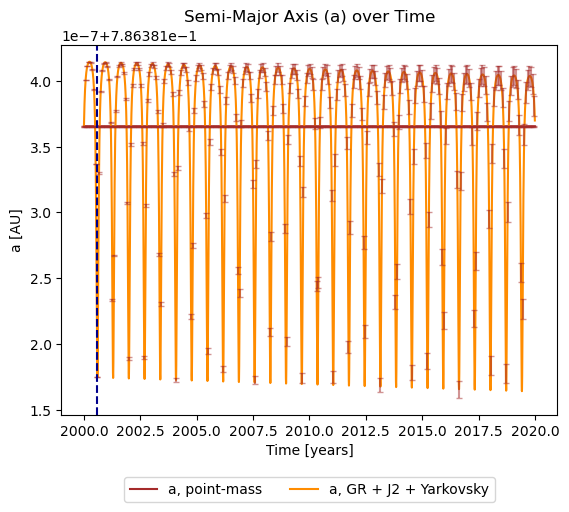

In [91]:
plt.plot(epochs_years, a_kep_1_AU, color='brown', label='a, point-mass')
plt.plot(epochs_years, a_kep_2_AU, color='darkorange', label='a, GR + J2 + Yarkovsky')

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_1_AU)[idx],
    yerr=a_kep_1_AU_error_bars[idx],
    fmt='none',
    ecolor='brown',
    alpha=0.5,
    capsize=2
)

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_2_AU)[idx],
    yerr=a_kep_2_AU_error_bars[idx],
    fmt='none',
    ecolor='brown',
    alpha=0.5,
    capsize=2
)

plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5)

plt.title('Semi-Major Axis (a) over Time')
plt.xlabel('Time [years]')
plt.ylabel('a [AU]')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()

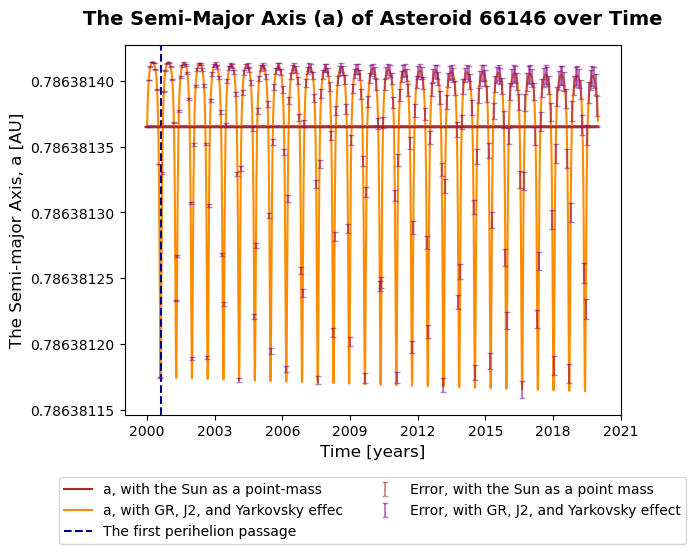

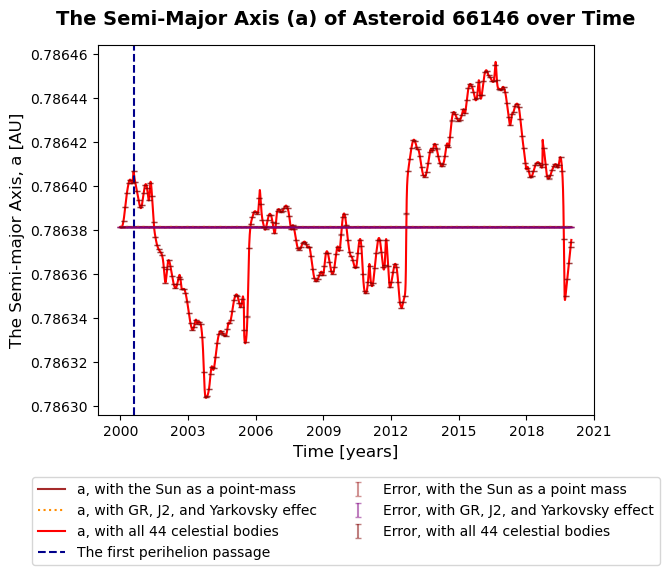

In [ ]:
# Plot 1

plt.plot(epochs_years, a_kep_1_AU, color='brown', label='a, with the Sun as a point-mass')
plt.plot(epochs_years, a_kep_2_AU, color='darkorange', label='a, with GR, J2, and Yarkovsky effec')
# plt.plot(epochs_years, a_kep_3_AU, color='red', label='All bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_1_AU)[idx],
    yerr=a_kep_1_AU_error_bars[idx],
    fmt='none',
    ecolor='brown',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_2_AU)[idx],
    yerr=a_kep_2_AU_error_bars[idx],
    fmt='none',
    ecolor='purple',
    alpha=0.5,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Semi-Major Axis (a) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Semi-major Axis, a [AU]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

# Set ticks at 2000, 2002, 2004, ...
xmin, xmax = plt.xlim()
ticks = np.arange(np.floor(xmin/2)*2 + 2, np.ceil(xmax/2)*2, 3)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])

plt.show()


#Plot 2

plt.plot(epochs_years, a_kep_1_AU, color='brown', label='a, with the Sun as a point-mass')
plt.plot(epochs_years, a_kep_2_AU, color='darkorange', linestyle=':', label='a, with GR, J2, and Yarkovsky effec')
plt.plot(epochs_years, a_kep_3_AU, color='red', label='a, with all 44 celestial bodies')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_1_AU)[idx],
    yerr=a_kep_1_AU_error_bars[idx],
    fmt='none',
    ecolor='brown',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx],
    np.array(a_kep_2_AU)[idx],
    yerr=a_kep_2_AU_error_bars[idx],
    fmt='none',
    ecolor='purple',
    alpha=0.5,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx - 100],
    np.array(a_kep_3_AU)[idx - 100],
    yerr=a_kep_3_AU_error_bars[idx - 100],
    fmt='none',
    ecolor='maroon',
    alpha=0.5,
    capsize=2,
    label='Error, with all 44 celestial bodies'
)


plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Semi-Major Axis (a) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Semi-major Axis, a [AU]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()

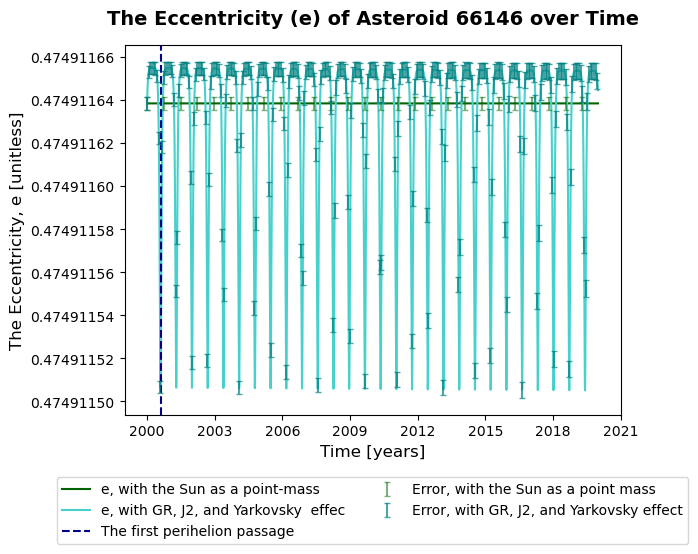

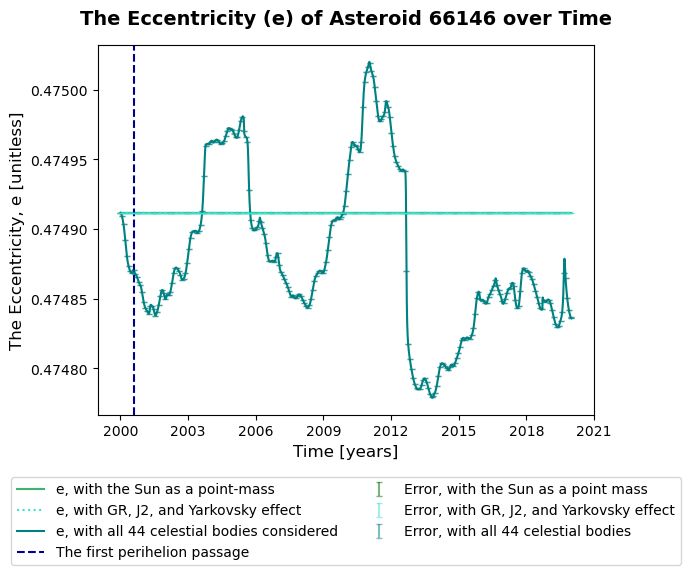

In [122]:
# Plot 3

plt.plot(epochs_years, e_kep_1, color='darkgreen', label='e, with the Sun as a point-mass')
plt.plot(epochs_years, e_kep_2, color='mediumturquoise', label='e, with GR, J2, and Yarkovsky  effec')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

# Create a sparser index just for the flat line's error bars
sparse_idx = idx[::10] # Change '5' to a higher number if it's still too dense

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(e_kep_1)[sparse_idx],
    yerr=np.array(e_kep_1_error_bars)[sparse_idx],
    fmt='none',
    ecolor='darkgreen',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

plt.errorbar(
    epochs_years[idx],
    np.array(e_kep_2)[idx],
    yerr=e_kep_2_error_bars[idx],
    fmt='none',
    ecolor='teal',
    alpha=0.7,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Eccentricity (e) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Eccentricity, e [unitless]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


#Plot 4

plt.plot(epochs_years, e_kep_1, color='mediumseagreen', label='e, with the Sun as a point-mass')
plt.plot(epochs_years, e_kep_2, color='turquoise', linestyle=':', label='e, with GR, J2, and Yarkovsky effect')
plt.plot(epochs_years, e_kep_3, color='teal', label='e, with all 44 celestial bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(e_kep_1)[sparse_idx],
    yerr=np.array(e_kep_1_error_bars)[sparse_idx],
    fmt='none',
    ecolor='darkgreen',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

plt.errorbar(
    epochs_years[idx],
    np.array(e_kep_2)[idx],
    yerr=e_kep_2_error_bars[idx],
    fmt='none',
    ecolor='turquoise',
    alpha=0.5,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

# error bars only every ~100 points
plt.errorbar(
    epochs_years[idx - 100],
    np.array(e_kep_3)[idx - 100],
    yerr=e_kep_3_error_bars[idx - 100],
    fmt='none',
    ecolor='teal',
    alpha=0.5,
    capsize=2,
    label='Error, with all 44 celestial bodies'
)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Eccentricity (e) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Eccentricity, e [unitless]', fontsize=12)

# plt.legend()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()

<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:34: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:36: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:50: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:51: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:52: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will 

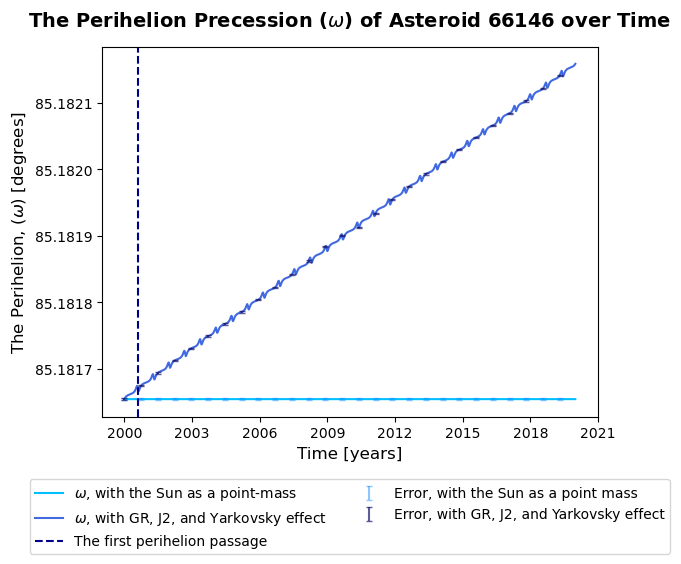

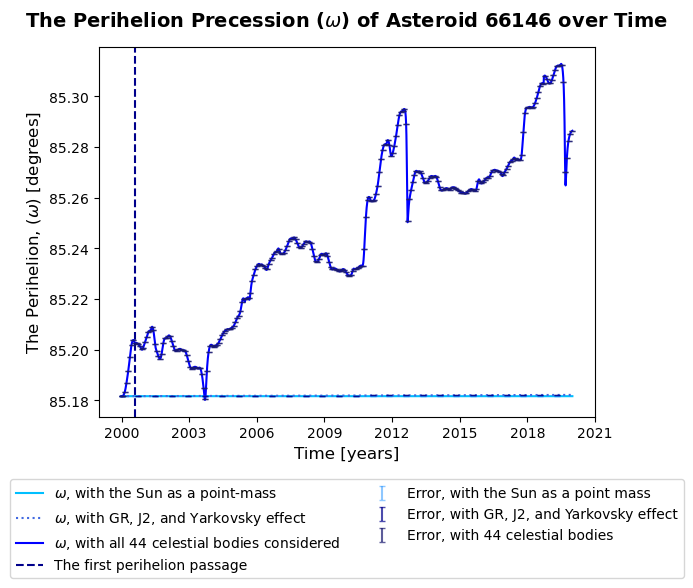

In [137]:
# Plot 5

plt.plot(epochs_years, omega_values_1, color='deepskyblue', label=f'$\omega$, with the Sun as a point-mass')
plt.plot(epochs_years, omega_values_2, color='royalblue', label=f'$\omega$, with GR, J2, and Yarkovsky effect')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

# Create a sparser index just for the flat line's error bars
sparse_idx = idx[::10] # Change '5' to a higher number if it's still too dense

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(omega_values_1)[sparse_idx],
    yerr=np.array(omega_values_1_error_bars)[sparse_idx],
    fmt='none',
    ecolor='dodgerblue',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(omega_values_2)[sparse_idx],
    yerr=omega_values_2_error_bars[sparse_idx],
    fmt='none',
    ecolor='midnightblue',
    alpha=0.7,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title(f'The Perihelion Precession ($\omega$) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Perihelion, ($\omega$) [degrees]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()


#Plot 6

plt.plot(epochs_years, omega_values_1, color='deepskyblue', label=f'$\omega$, with the Sun as a point-mass')
plt.plot(epochs_years, omega_values_2, color='royalblue', linestyle=':', label=f'$\omega$, with GR, J2, and Yarkovsky effect')
plt.plot(epochs_years, omega_values_3, color='blue', label=f'$\omega$, with all 44 celestial bodies considered')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(omega_values_1)[sparse_idx],
    yerr=np.array(omega_values_1_error_bars)[sparse_idx],
    fmt='none',
    ecolor='dodgerblue',
    alpha=0.5,
    capsize=2,
    label='Error, with the Sun as a point mass'
)

plt.errorbar(
    epochs_years[sparse_idx],
    np.array(omega_values_2)[sparse_idx],
    yerr=omega_values_2_error_bars[sparse_idx],
    fmt='none',
    ecolor='darkblue',
    alpha=0.7,
    capsize=2,
    label='Error, with GR, J2, and Yarkovsky effect'
)

plt.errorbar(
    epochs_years[idx],
    np.array(omega_values_3)[idx],
    yerr=omega_values_3_error_bars[idx],
    fmt='none',
    ecolor='midnightblue',
    alpha=0.7,
    capsize=2,
    label='Error, with 44 celestial bodies'
)


plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title(f'The Perihelion Precession ($\omega$) of Asteroid 66146 over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Perihelion, ($\omega$) [degrees]', fontsize=12)

# plt.legend()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.xticks(ticks, [f"{int(t)}" for t in ticks])
plt.show()